In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("/home/amirarsalan/projects/Data_Talks/Home_Work_2/car_fuel_efficiency.csv")

In [3]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
columns_to_use = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

In [5]:
car_fuel = df[columns_to_use]

array([[<Axes: title={'center': 'engine_displacement'}>,
        <Axes: title={'center': 'horsepower'}>],
       [<Axes: title={'center': 'vehicle_weight'}>,
        <Axes: title={'center': 'model_year'}>],
       [<Axes: title={'center': 'fuel_efficiency_mpg'}>, <Axes: >]],
      dtype=object)

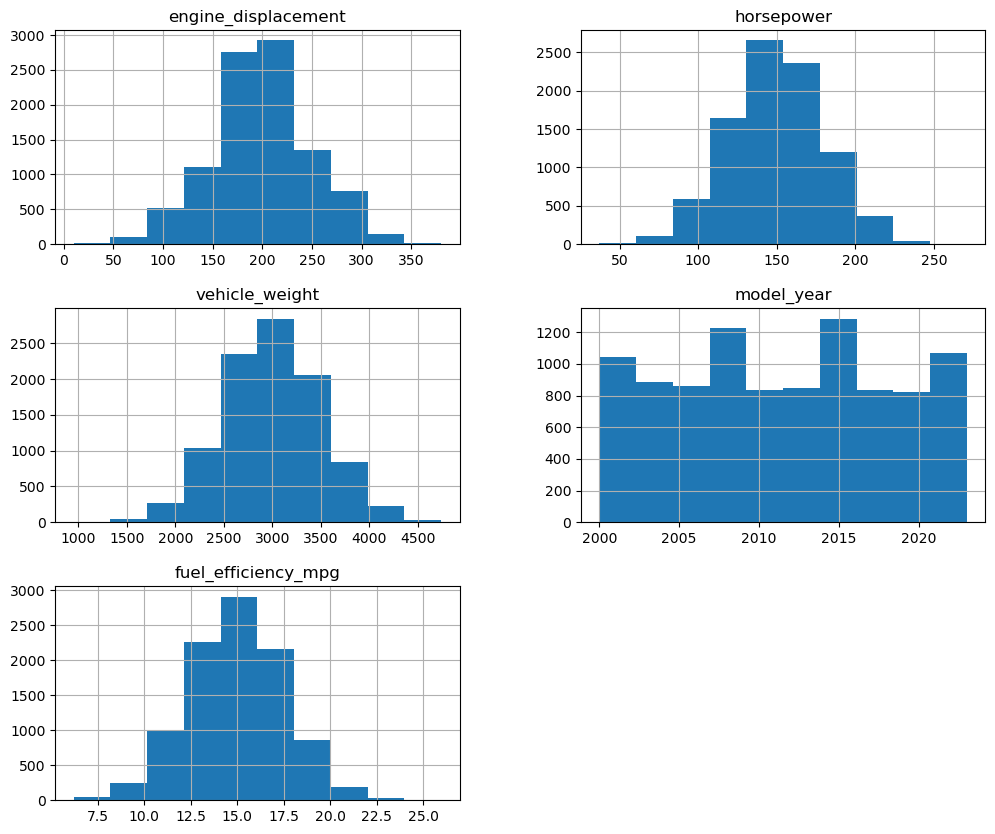

In [6]:
car_fuel.hist(figsize=(12, 10))

# Question-1

**There's one column with missing values. What is it?**

In [7]:
car_fuel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


# Question-2

**What's the median (50% percentile) for variable 'horsepower'?**

In [8]:
car_fuel['horsepower'].median()

149.0

# Prepare and split the dataset


**Shuffle the dataset (the filtered one you created above), use seed 42.**

In [9]:
np.random.seed(42)

In [10]:
idx = car_fuel.index

In [11]:
idx_numpy = np.array(idx)

In [12]:
np.random.shuffle(idx_numpy)

In [13]:
idx_numpy

array([ 483, 7506, 8795, ..., 5390,  860, 7270], shape=(9704,))

In [14]:
idx.values

array([   0,    1,    2, ..., 9701, 9702, 9703], shape=(9704,))

In [15]:
car_fuel_shuffled = car_fuel.iloc[idx_numpy, :]

In [16]:
car_fuel

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


In [17]:
car_fuel_shuffled

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
483,220,144.0,2535.887591,2009,16.642943
7506,160,141.0,2741.170484,2019,16.298377
8795,230,155.0,2471.880237,2017,18.591822
1688,150,206.0,3748.164469,2015,11.818843
6217,300,111.0,2135.716359,2006,19.402209
...,...,...,...,...,...
5734,210,163.0,1972.029124,2011,19.961672
5191,160,126.0,3011.588014,2009,14.651056
5390,290,187.0,2440.508039,2019,18.404435
860,260,129.0,1865.404480,2019,20.502460


**Split your data in train/val/test sets, with 60%/20%/20% distribution.**

In [18]:
n = len(df)

test = int(n * 0.2)
val = int(n * 0.2)
train = int(n - test - val)

test, val, train

(1940, 1940, 5824)

In [19]:
n

9704

In [20]:
test + train + val

9704

In [21]:
test_df = car_fuel_shuffled[: test]
val_df = car_fuel_shuffled[test: test+val]
train_df = car_fuel_shuffled[test+val: ]

In [22]:
len(test_df), len(val_df), len(train_df)

(1940, 1940, 5824)

# Question 3

**We need to deal with missing values for the column from Q1.**


**We have two options: fill it with 0 or with the mean of this variable.**

**Try both options. For each, train a linear regression model without regularization using the code from the lessons.**

In [23]:
train_df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
8064,70,87.0,3346.134219,2004,13.085351
6622,280,147.0,4193.817815,2017,9.385060
2155,240,137.0,2471.172629,2010,17.697460
8916,240,127.0,4044.606636,2000,9.298735
3274,280,NaN,3039.297482,2011,14.724394


In [24]:
train_df_mean = train_df.horsepower.mean()

In [25]:
with_0, with_mean = train_df.fillna(0), train_df.fillna(train_df_mean)

In [26]:
with_0

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
8064,70,87.0,3346.134219,2004,13.085351
6622,280,147.0,4193.817815,2017,9.385060
2155,240,137.0,2471.172629,2010,17.697460
8916,240,127.0,4044.606636,2000,9.298735
3274,280,0.0,3039.297482,2011,14.724394
...,...,...,...,...,...
5734,210,163.0,1972.029124,2011,19.961672
5191,160,126.0,3011.588014,2009,14.651056
5390,290,187.0,2440.508039,2019,18.404435
860,260,129.0,1865.404480,2019,20.502460


In [27]:
with_mean

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
8064,70,87.000000,3346.134219,2004,13.085351
6622,280,147.000000,4193.817815,2017,9.385060
2155,240,137.000000,2471.172629,2010,17.697460
8916,240,127.000000,4044.606636,2000,9.298735
3274,280,149.739967,3039.297482,2011,14.724394
...,...,...,...,...,...
5734,210,163.000000,1972.029124,2011,19.961672
5191,160,126.000000,3011.588014,2009,14.651056
5390,290,187.000000,2440.508039,2019,18.404435
860,260,129.000000,1865.404480,2019,20.502460


Linear Regression: The Matrix ApproachIn linear algebra terms, performing linear regression is essentially finding the best-fit vector in a high-dimensional space. By using the matrix form (vectorization), we avoid slow for loops and leverage optimized libraries like NumPy.1. Defining the ComponentsTo represent the problem with $m$ training examples and $n$ features:Design Matrix ($X$): A matrix where each row represents an observation and each column represents a feature. We add a column of $1$s to account for the intercept (bias) term $\theta_0$.$$X = \begin{bmatrix} 1 & x_{11} & x_{12} & \dots & x_{1n} \\ 1 & x_{21} & x_{22} & \dots & x_{2n} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & x_{m1} & x_{m2} & \dots & x_{mn} \end{bmatrix} \in \mathbb{R}^{m \times (n+1)}$$Parameter Vector ($\theta$): The weights/coefficients the model needs to learn.$$\theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\ \theta_n \end{bmatrix} \in \mathbb{R}^{(n+1) \times 1}$$Target Vector ($y$): The actual values observed in the training set.$$y = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_m \end{bmatrix} \in \mathbb{R}^{m \times 1}$$2. The Hypothesis FunctionThe model’s prediction $\hat{y}$ is simply the product of the design matrix and the parameter vector:$$\hat{y} = X\theta$$This single matrix operation calculates the prediction for every single example in the dataset simultaneously.3. The Cost Function (Mean Squared Error)To find the "best" $\theta$, we minimize the cost function $J(\theta)$. In matrix form, the sum of squared errors is represented as:$$J(\theta) = \frac{1}{2m} (X\theta - y)^T (X\theta - y)$$Note: Multiplying the transpose of the error vector $(X\theta - y)^T$ by itself $(X\theta - y)$ is equivalent to the dot product of the errors, which results in the sum of squares: $\sum (h(x^{(i)}) - y^{(i)})^2$.4. The Normal Equation (The Analytical Solution)Instead of using iterative methods like Gradient Descent, we can find the optimal $\theta$ by taking the partial derivative of $J(\theta)$ with respect to $\theta$ and setting it to zero:$$\nabla_\theta J(\theta) = \frac{1}{m} X^T (X\theta - y) = 0$$Solving for $\theta$ gives us the Normal Equation:$$X^T X \theta = X^T y$$$$\hat{\theta} = (X^T X)^{-1} X^T y$$This formula provides the closed-form solution directly, provided that the matrix $X^T X$ is invertible (non-singular).Why Use the Matrix Form in Jupyter?Computational Efficiency: Vectorized operations are significantly faster in Python because they utilize low-level BLAS (Basic Linear Algebra Subprograms) optimizations.Code Readability: Complex summations are reduced to simple matrix multiplications.Scalability: This framework is the foundation for more advanced algorithms like Ridge/Lasso regression and Neural Networks.

In [107]:
def linear_reg(df):
    X = df.drop('fuel_efficiency_mpg', axis=1)
    y = df['fuel_efficiency_mpg']
    X[1] = 1
    
    beta = np.linalg.inv(X.T @ X) @ X.T @ y

    return beta

In [108]:
def normlize(df):
    df_copy = df.drop('fuel_efficiency_mpg', axis=1)
    columns = df_copy.columns
    
    for column in columns:
        df_copy[column] = (df_copy[column] - df_copy[column].mean()) / np.std(df_copy[column])
        
        
        
    df_copy['fuel_efficiency_mpg'] = df['fuel_efficiency_mpg']
    
    return df_copy

$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2}$$

In [109]:
def evulation(X, y, beta):
    X[1] = 1
    
    beta_n = np.array(beta)
    
    y_hat = X @ beta_n
    
    return round(np.sqrt(np.mean((y_hat - y) ** 2)), 2)
    

In [110]:
def normilize_val_test(df_val, df_train, mode):
    X = df_val.drop('fuel_efficiency_mpg', axis=1)
    y = df_val['fuel_efficiency_mpg']

    if mode == '0':
        X['horsepower'] = X['horsepower'].fillna(0)
    else:
        X['horsepower'] = X['horsepower'].fillna(df_train['horsepower'].mean())
            
    columns = X.columns
    for column in columns:
        X[column] = (X[column] - df_train[column].mean()) / np.std(df_train[column])

    
    return X, y

**When we use the Normal Equation without normalization, the resulting coefficients ($\beta$) are in their original units. For example, a coefficient might represent 'price change per square meter.'However, after normalization, the features are squeezed into a shared scale (like 0 to 1). Consequently, the coefficients also change their scale to compensate. These are called Standardized Coefficients, and while they are great for comparing which feature is more 'important,' they lose their direct physical meaning (units).**

***with mean***

In [111]:
with_mean_norm = normlize(with_mean)

In [112]:
reg_mean = linear_reg(with_mean)
reg_mean_norm = linear_reg(with_mean_norm)
reg_mean_norm

0     0.008217
1     0.292812
2    -2.500992
3     0.003651
4    14.992539
dtype: float64

In [113]:
X_val, y_val = normilize_val_test(val_df, with_mean, 1)
X_val, y_val

(      engine_displacement  horsepower  vehicle_weight  model_year
 2227            -1.821851   -0.198297       -0.169449    0.223663
 2145            -0.007339   -1.545616       -0.298558   -0.528510
 1322            -0.410564   -0.854683        1.653636   -0.227641
 1603             1.202336    0.354450       -0.697296    0.975836
 6927             0.194274   -0.647403        0.007759    0.975836
 ...                   ...         ...             ...         ...
 254             -1.620239    0.872650        0.159810   -0.678945
 5696             0.395886    0.000000       -1.834799   -0.979814
 3161            -1.015401    2.599982        0.078489    1.126271
 4319            -0.007339   -0.267390       -0.386086    0.825401
 4301             0.597499   -0.163750        0.168673    0.374098
 
 [1940 rows x 4 columns],
 2227    15.346002
 2145    16.294345
 1322    10.643505
 1603    16.908809
 6927    14.551272
           ...    
 254     14.773141
 5696    19.919012
 3161    15.3162

In [114]:
evulation(X_val, y_val, reg_mean_norm)

np.float64(0.45)

***with_0***

In [115]:
with_0_norm = normlize(with_0)

In [116]:
reg_0 = linear_reg(with_0)
reg_0

0   -7.729176e-07
1    3.775739e-03
2   -5.012756e-03
3    1.293705e-03
4    2.690244e+01
dtype: float64

In [117]:
reg_0_norm = linear_reg(with_0_norm)
reg_0

0   -7.729176e-07
1    3.775739e-03
2   -5.012756e-03
3    1.293705e-03
4    2.690244e+01
dtype: float64

In [118]:
X_val, y_val = normilize_val_test(val_df, with_0, 0)
X_val, y_val

(      engine_displacement  horsepower  vehicle_weight  model_year
 2227            -1.821851    0.103236       -0.169449    0.223663
 2145            -0.007339   -0.705001       -0.298558   -0.528510
 1322            -0.410564   -0.290521        1.653636   -0.227641
 1603             1.202336    0.434820       -0.697296    0.975836
 6927             0.194274   -0.166177        0.007759    0.975836
 ...                   ...         ...             ...         ...
 254             -1.620239    0.745681        0.159810   -0.678945
 5696             0.395886    0.000000       -1.834799   -0.979814
 3161            -1.015401    1.781882        0.078489    1.126271
 4319            -0.007339    0.061788       -0.386086    0.825401
 4301             0.597499    0.123960        0.168673    0.374098
 
 [1940 rows x 4 columns],
 2227    15.346002
 2145    16.294345
 1322    10.643505
 1603    16.908809
 6927    14.551272
           ...    
 254     14.773141
 5696    19.919012
 3161    15.3162

In [119]:
evulation(X_val, y_val, reg_0_norm)

np.float64(0.49)

# Question 4

### Now let's train a regularized linear regression.
For this question, fill the NAs with 0.  

Try different values of r from this list: [0, 0.01, 0.1, 1, 5, 10, 100].  

Use RMSE to evaluate the model on the validation dataset.  

Round the RMSE scores to 2 decimal digits.  

**Which r gives the best RMSE?**

Understanding Regularization and Ridge Regression1. The Concept: Overfitting vs. RegularizationIn mathematical modeling, overfitting occurs when a model learns the noise in the training data rather than the signal. Regularization acts as a "penalty" system that prevents the model's coefficients ($\beta$) from becoming too large, forcing the model to remain simple and generalize better to new data.2. The Mathematical FoundationIn Ridge Regression (Tikhonov Regularization), we modify the standard Normal Equation by adding a regularization term $rI$ to the matrix product $X^T X$:$$\hat{\theta} = (X^T X + rI)^{-1} X^T y$$$r$ (Regularization Strength): A hyperparameter that controls the magnitude of the penalty.$I$ (Identity Matrix): Ensures that the matrix $(X^T X + rI)$ is non-singular and invertible, which is a key advantage for Mathematical Engineers when dealing with collinear data.3. Tuning the Hyperparameter ($r$)We evaluate different values of $r$ (e.g., $0, 0.01, 0.1, 1, 5, 10, 100$):$r = 0$: Equivalent to standard OLS (no regularization).Optimal $r$: The value that balances the trade-off between bias and variance.High $r$: May lead to underfitting as coefficients are pushed too close to zero.4. Implementation StrategyTo find the best model, we follow these steps:Iterate: Compute the optimal $\beta$ for each $r$ value in the list.Predict: Use the resulting model to predict values on the Validation Set.Evaluate: Calculate the RMSE (Root Mean Square Error) for each prediction.Select: The $r$ that produces the lowest RMSE is chosen as the final hyperparameter.

In [120]:
def linear_reg_r_0(df, r):
    X = df.drop('fuel_efficiency_mpg', axis=1)
    y = df['fuel_efficiency_mpg']
    X[1] = 1
    I = np.eye(X.shape[1])
    
    beta = np.linalg.inv(X.T @ X + r * I) @ X.T @ y

    return beta

In [121]:
list_r = [0, 0.01, 0.1, 1, 5, 10, 100]
for number in list_r:
    beta_0_norm = linear_reg_r_0(with_0_norm, number)
    print(evulation(X_val, y_val, beta_0_norm))

0.49
0.49
0.49
0.49
0.49
0.49
0.54


# Question 5

***We used seed 42 for splitting the data.***   ***Let's find out how selecting the seed influences our score.***   
***Try different seed values: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9].***   
***For each seed, do the train/validation/test split with 60%/20%/20% distribution.***   
***Fill the missing values with 0 and train a model without regularization.***  
***For each seed, evaluate the model on the validation dataset and collect the RMSE scores.***   
***What's the standard deviation of all the scores? To compute the standard deviation, use np.std.***   
***Round the result to 3 decimal digits (round(std, 3))***   

In [140]:
def n_seeds(df:pd.DataFrame, nums:list[int]) -> float:
    RMES = []
    df = df.fillna(0)
    for num in nums:
        np.random.seed(num)
        df = df.reset_index(drop=True)
        idx = df.index
        idx_numpy = np.array(idx)
        np.random.shuffle(idx_numpy)
        
        n = len(df)
        
        
        car_fuel_shuffled = df.iloc[idx_numpy, :]
        
        test = int(n * 0.2)
        val = int(n * 0.2)
        train = int(n - test - val)

        train_df = car_fuel_shuffled[:train]
        val_df = car_fuel_shuffled[train : train + val]
        test_df = car_fuel_shuffled[train + val :]

        train_df_n = normlize(train_df)
        X_val_n, y_val_n =  normilize_val_test(val_df, train_df, 0)
        
        beta = linear_reg(train_df_n)
        
        
        RMES.append(evulation(X_val_n, y_val_n, beta))
        
    return RMES

In [141]:
car_fuel

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


In [142]:
np.round(np.std(n_seeds(car_fuel, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])), 3)

np.float64(0.007)

# Question 6


***Split the dataset like previously, use seed 9.***   
***Combine train and validation datasets.***   
***Fill the missing values with 0 and train a model with r=0.001.***   
***What's the RMSE on the test dataset?***   


In [145]:
def concat_val_train(df):
    df = df.fillna(0)
    np.random.seed(9)
    idx = df.index
    idx_numpy = np.array(idx)
    np.random.shuffle(idx_numpy)
    
    n = len(df)
    
    
    car_fuel_shuffled = df.iloc[idx_numpy, :]
    
    test = int(n * 0.2)
    val = int(n * 0.2)
    train = int(n - test - val)

    train_df = car_fuel_shuffled[:train]
    val_df = car_fuel_shuffled[train : train + val]
    test_df = car_fuel_shuffled[train + val :]

    concated_train = pd.concat([train_df, val_df])
    
    
    X_val_n, y_val_n =  normilize_val_test(test_df, train_df, 0)
    
    train_df_n = normlize(concated_train)    
    beta = linear_reg(train_df_n)    

    return evulation(X_val_n, y_val_n, beta)

In [146]:
concat_val_train(car_fuel)

np.float64(0.52)